## Preliminar

In [1]:
import numpy as np


const = np.array([1.0])


def gauss(x: np.ndarray, mu: np.ndarray, sigma: float, A: float) -> np.ndarray:
    """
    x.shape = (N, d)
    mu.shape = (d,)

    Retorna un vector de forma (N,).
    """
    diff = x - mu
    norm2 = np.sum(diff**2, axis=1)
    return A * np.exp(-norm2 / (2 * sigma**2))


def constante_en_intervalo(
    x: np.ndarray,
    const: float,
    a: np.ndarray,
    b: np.ndarray,
) -> np.ndarray:
    """
    x.shape = (N,d)
    a.shape = (d,)
    b.shape = (d,)

    Retorna const sobre el hiperrrectángulo
    [a₁,b₁]×⋯×[a_d,b_d].
    """
    inside = np.all((a <= x) & (x <= b), axis=1)
    return const * inside


def funcion_constante(z: np.ndarray, const: float) -> np.ndarray:
    """
    z.shape = (N,d)
    """
    return np.full((z.shape[0],), const)


def kernel_gaussiano(x: np.ndarray, y: np.ndarray, sigma_K: float) -> np.ndarray:
    """
    x.shape = (N_consumer,d_x)
    y.shape = (N_resource,d_y)

    Retorna una matriz de forma
        (N_consumer,N_resource).
    """
    diff = x[:, None, :] - y[None, :, :]
    norm2 = np.sum(diff**2, axis=2)
    exp = np.exp(-norm2 / (2 * sigma_K**2))
    return exp / (sigma_K * np.sqrt(2 * np.pi))

def kernel_pinzon_semilla(x,y,sigma_tamaño,sigma_dureza):

    # tamaño
    tamaño_diff = y[None, :, 0] - x[:, None, 0]

    kernel_tamaño = np.exp(
        -tamaño_diff**2 /(2*sigma_tamaño**2)
    )

    # dureza
    dureza_diff = x[:, None, 1] - y[None, :, 1]

    kernel_dureza = 1 / (
        1 + np.exp(-sigma_dureza * dureza_diff)
    )

    return kernel_tamaño * kernel_dureza


def supply_rate_gaussiano(y: np.ndarray, c: np.ndarray, sigma_in: float, M_in: float) -> np.ndarray:
    """
    y.shape = (N,d)
    c.shape = (1,d)
    """
    norm2 = np.sum((y-c)**2, axis=1)
    exp = np.exp(-norm2 / (2 * sigma_in**2))
    return M_in * exp / (sigma_in * np.sqrt(2 * np.pi))

In [2]:
from src import Model

# Todos los valores son adimensionales normalizados en [0,1]

# Largo del pico, grosor del pico
consumer_domain = np.array([[0, 1], [0, 1]])
# Tamaño de la semilla, dureza de la semilla 
resource_domain = np.array([[0, 1], [0, 1]])

## Especiación

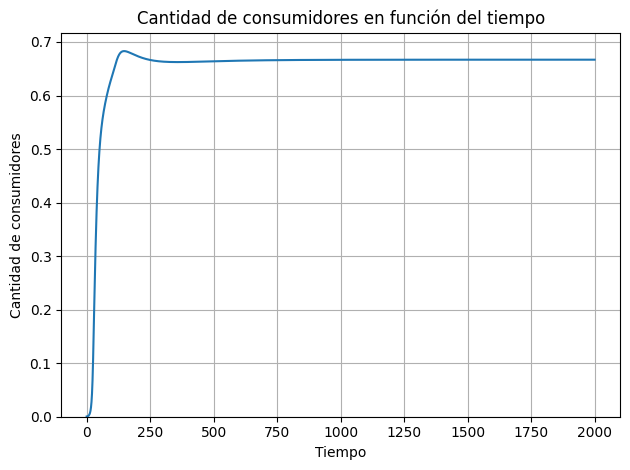

Frames totales: 1000, intervalo: 40.
Frame: 0.0.
Frame: 0.0.
Frame: 50.0.
Frame: 100.0.
Frame: 150.0.
Frame: 200.0.
Frame: 250.0.
Frame: 300.0.
Frame: 350.0.
Frame: 400.0.
Frame: 450.0.
Frame: 500.0.
Frame: 550.0.
Frame: 600.0.
Frame: 650.0.
Frame: 700.0.
Frame: 750.0.
Frame: 800.0.
Frame: 850.0.
Frame: 900.0.
Frame: 950.0.


In [3]:
Pinzones = Model(
    consumer_domain=consumer_domain,
    resource_domain=resource_domain,
    mutation_rate=0.00001,
)

Pinzones.set_consumer_growth_rate(lambda x: funcion_constante(x, const=2.0))
Pinzones.set_consumer_decay(
    lambda x: funcion_constante(x, const=0.07) + 0.25*x[:,1]**2
)  # la población muere

Pinzones.set_resource_supply_rate(
    lambda y: (
        supply_rate_gaussiano(y, np.array([[0.25,0.25]]), sigma_in=1.5/12, M_in=0.72)+
        supply_rate_gaussiano(y, np.array([[0.4167,0.666]]), sigma_in=1.5/12, M_in=0.63)+
        supply_rate_gaussiano(y, np.array([[0.75,0.666]]), sigma_in=1.5/12, M_in=0.42) 
    ) / 3
)
Pinzones.set_resource_decay(lambda y: funcion_constante(y, const=0.06))

Pinzones.set_resource_consumer_kernel(
    lambda x, y: 1.5 * kernel_pinzon_semilla(x, y, sigma_tamaño=0.04, sigma_dureza=16.0)
    #lambda x, y: kernel_gaussiano(x, y, sigma_K=0.6/12)
)

Pinzones.set_initial_data(
    initial_consumer_distribution=lambda x: gauss(x, np.array([0.5, 0.5]), 0.2/12, 0.25),
    initial_resource_distribution=lambda y: constante_en_intervalo(
        y, 10.0, -2 * const, 0.25 * const
    ),  # ignorado cuando se usa recurso estacionario
)

T = 2000

Pinzones.solve_by_finite_differences(
    T=T,
    n_t=3 * T,
    n_x=(51, 51),
    n_y=(51, 51),
    border_type="neumann",
    theta=0.5,
    use_stationary_resource=True,
)

Pinzones.plot.consumer_quantity()
Pinzones.plot.solution_2D_animation(
    solution="consumer", 
    speed=6.0,
    title="Evolución de la densidad de aves.",
    xlabel="Largo del pico",
    ylabel="Grosor del pico",
)

In [4]:
Pinzones.plot.solution_2D_animation(
    solution="resource", 
    speed=6.0,
    title="Evolución de la densidad de semillas.",
    xlabel="Tamaño de la semilla",
    ylabel="Dureza de la semilla",
)

Frames totales: 1000, intervalo: 40.
Frame: 0.0.
Frame: 0.0.
Frame: 50.0.
Frame: 100.0.
Frame: 150.0.
Frame: 200.0.
Frame: 250.0.
Frame: 300.0.
Frame: 350.0.
Frame: 400.0.
Frame: 450.0.
Frame: 500.0.
Frame: 550.0.
Frame: 600.0.
Frame: 650.0.
Frame: 700.0.
Frame: 750.0.
Frame: 800.0.
Frame: 850.0.
Frame: 900.0.
Frame: 950.0.
